In [1]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import repeat
from random import shuffle
from collections import Counter
import time

def points_within_circle(radius, center=(0, 0), number_of_points=100):
    center_x, center_y = center
    r = radius * np.sqrt(np.random.random((number_of_points,)))
    theta = np.random.random((number_of_points,)) * 2 * np.pi
    # print('r', r)
    # print('theta', theta)
    x = center_x + r * np.cos(theta)  # use cosine to find x values
    y = center_y + r * np.sin(theta)  # use sine to find y values
    # print('x', x)
    # print('y', y)
    return x, y

X = np.arange(0, 8)                  # X [0 1 2 3 4 5 6 7]
# fig, ax = plt.subplots()

oranges_x, oranges_y = points_within_circle(1.6, (5, 2), 100)
lemons_x, lemons_y = points_within_circle(1.9, (2, 5), 100)

# print(oranges_x, oranges_y)
# type(oranges_x)                          # numpy.ndarray

In [2]:
class Perceptron:
    def __init__(self, weights):
        """
        Weights can be a numpy array, list or a tuple or a tuple with the actual values of the weights.
        The number of input values is indirectly defined by the length of weights
        """
        self.weights = np.array(weights)

    def __call__(self, in_data):
        weighted_input = self.weights * in_data
        weighted_sum = weighted_input.sum()
        return weighted_sum

    
p = Perceptron(weights=[-0.45, 0.5])

for point in zip(oranges_x[:10], oranges_y[:10]):
    res = p(point)
    print(res, end=", ")

print('\n')

for point in zip(lemons_x[:10], lemons_y[:10]):
    res = p(point)
    print(res, end=", ")

-2.083607101285457, -1.5427743506296845, -0.7141182112912334, -0.7678793426649877, -1.2781593691328332, -1.377053007386138, -0.743023636864973, -0.6023407875295552, -0.977907428126408, -1.515272440232498, 

2.6419838512973546, 1.058987383611841, 2.1615776514508456, 1.2549391322991357, 0.37385414324693755, 2.148740292130335, 1.8938828542081705, 0.6343262495434221, 1.8807442150282982, 1.945073965030588, 

In [3]:
"""
We can see that we get a negative value, if we input an orange and a positive value, if we input a lemon. With
this knowledge, we can calculate the accuracy of our neural network on this data set:
"""
evaluation = Counter()

for point in zip(oranges_x, oranges_y):         # Oranges
    res = p(point)
    if res < 0:
        evaluation['corrects'] += 1
    else:
        evaluation['wrongs'] += 1

# print('\n', evaluation)

for point in zip(lemons_x, lemons_y):             #lemons
    res = p(point)
    if res >= 0:
        evaluation['corrects'] += 1
    else:
        evaluation['wrongs'] += 1

# print('\n', evaluation)                     # Counter({'corrects': 200})

In [4]:
"""
How does the calculation work? We multiply the input values with the weights and get negative and positive
values. Let us examine what we get, if the calculation results in 0:
        w1 ⋅ x1 + w2 ⋅ x2 = 0

We can change this equation into
        x2 = − w1/w2 ⋅ x1

We can compare this with the general form of a straight line
        y = m ⋅ x + c

where:
        • m is the slope or gradient of the line.
        • c is the y-intercept of the line.
        • x is the independent variable of the function.

We can easily see that our equation corresponds to the definition of a line and the slope (aka gradient) m is
−w1/w2 and c is equal to 0.

This is a straight line separating the oranges and lemons, which is called the decision boundary.

We visualize this with the following Python program:
"""

'\nHow does the calculation work? We multiply the input values with the weights and get negative and positive\nvalues. Let us examine what we get, if the calculation results in 0:\n        w1 ⋅ x1 + w2 ⋅ x2 = 0\n\nWe can change this equation into\n        x2 = − w1/w2 ⋅ x1\n\nWe can compare this with the general form of a straight line\n        y = m ⋅ x + c\n\nwhere:\n        • m is the slope or gradient of the line.\n        • c is the y-intercept of the line.\n        • x is the independent variable of the function.\n\nWe can easily see that our equation corresponds to the definition of a line and the slope (aka gradient) m is\n−w1/w2 and c is equal to 0.\n\nThis is a straight line separating the oranges and lemons, which is called the decision boundary.\n\nWe visualize this with the following Python program:\n'

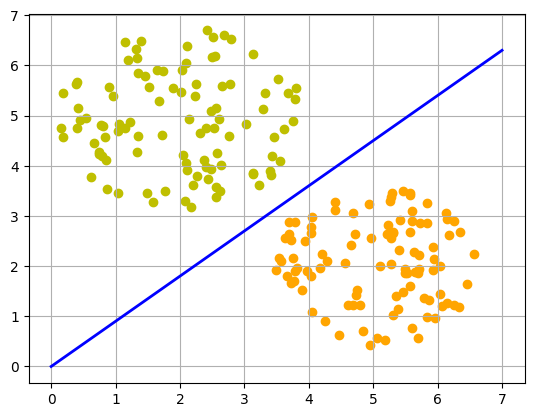

0.9


In [5]:
fig, ax = plt.subplots()

ax.scatter(oranges_x, oranges_y, c="orange", label="oranges")

slope = 0.45 / 0.5                   # W1 / W2

ax.plot(X, slope * X, 'b-', linewidth=2)
ax.scatter(lemons_x, lemons_y, c="y", label="lemons")

ax.grid()
plt.show()
print(slope)  